In [1]:
%load_ext autoreload
%autoreload 2

In [5]:
!pip install networkx

   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 2.0/2.0 MB 35.6 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


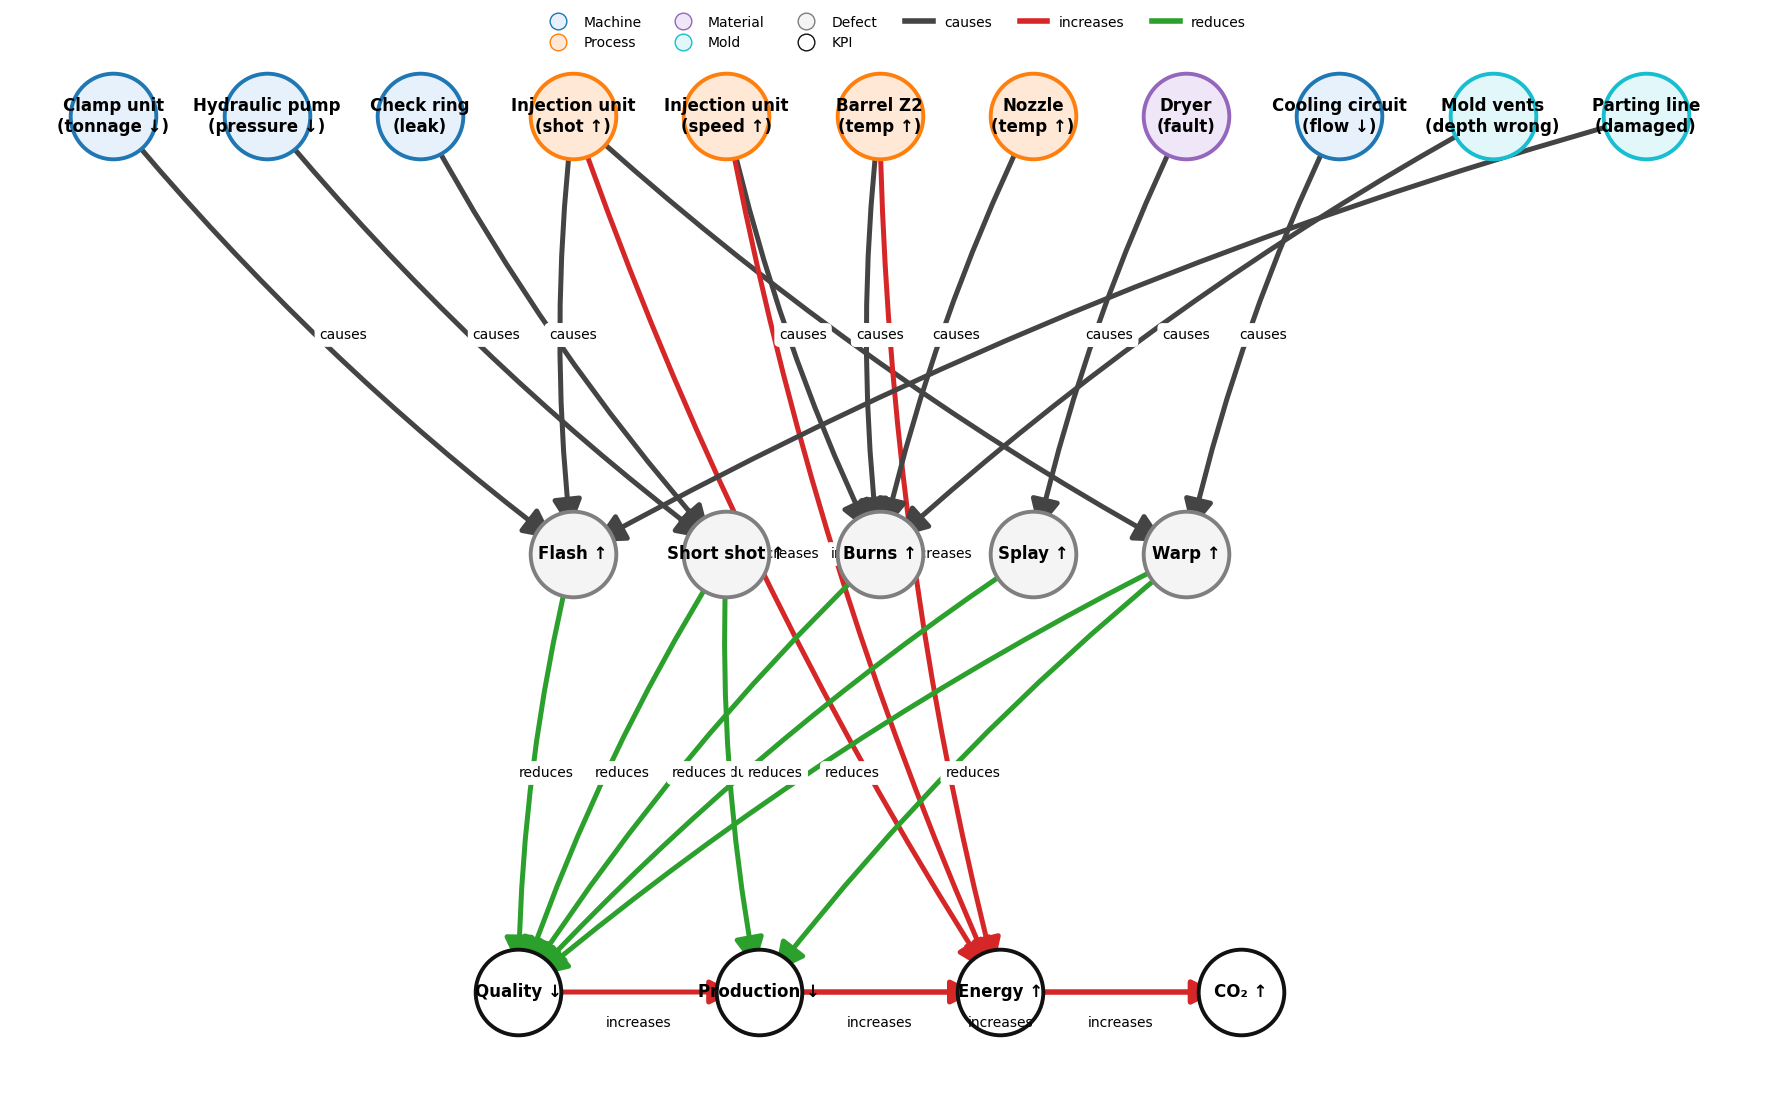

In [16]:
# %%
# XQuality causal graph — spacing + KPI label fix (works in Jupyter)

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from pathlib import Path

# -------------------- Data --------------------
nodes = [
    ("CLAMP",   "Clamp unit\n(tonnage ↓)", "machine"),
    ("HPUMP",   "Hydraulic pump\n(pressure ↓)", "machine"),
    ("SHOT",    "Injection unit\n(shot ↑)", "process"),
    ("SPEED",   "Injection unit\n(speed ↑)", "process"),
    ("BZ2",     "Barrel Z2\n(temp ↑)", "process"),
    ("NOZZLE",  "Nozzle\n(temp ↑)", "process"),
    ("NRV",     "Check ring\n(leak)", "machine"),
    ("DRYER",   "Dryer\n(fault)", "material"),
    ("COOL",    "Cooling circuit\n(flow ↓)", "machine"),
    ("VENT",    "Mold vents\n(depth wrong)", "mold"),
    ("PLINE",   "Parting line\n(damaged)", "mold"),
    ("FLASH",   "Flash ↑", "defect"),
    ("SHORT",   "Short shot ↑", "defect"),
    ("BURNS",   "Burns ↑", "defect"),
    ("SPLAY",   "Splay ↑", "defect"),
    ("WARP",    "Warp ↑", "defect"),
    ("QUAL",    "Quality ↓", "kpi"),
    ("PROD",    "Production ↓", "kpi"),
    ("ENERGY",  "Energy ↑", "kpi"),
    ("CO2",     "CO₂ ↑", "kpi"),
]

edges = [
    ("CLAMP","FLASH","causes"),
    ("HPUMP","SHORT","causes"),
    ("NRV","SHORT","causes"),
    ("SHOT","FLASH","causes"),
    ("SHOT","WARP","causes"),
    ("SPEED","BURNS","causes"),
    ("BZ2","BURNS","causes"),
    ("NOZZLE","BURNS","causes"),
    ("DRYER","SPLAY","causes"),
    ("COOL","WARP","causes"),
    ("VENT","BURNS","causes"),
    ("PLINE","FLASH","causes"),
    ("FLASH","QUAL","reduces"),
    ("SHORT","QUAL","reduces"),
    ("BURNS","QUAL","reduces"),
    ("SPLAY","QUAL","reduces"),
    ("WARP","QUAL","reduces"),
    ("SHORT","PROD","reduces"),
    ("WARP","PROD","reduces"),
    ("BZ2","ENERGY","increases"),
    ("SPEED","ENERGY","increases"),
    ("SHOT","ENERGY","increases"),
    ("ENERGY","CO2","increases"),
    ("PROD","ENERGY","increases"),
    ("PROD","CO2","increases"),
    ("QUAL","PROD","increases"),
]

theme_color = {
    "machine": ("#1f77b4", "#e6f1fb"),
    "process": ("#ff7f0e", "#ffe9d6"),
    "material":("#9467bd", "#efe6f7"),
    "mold":    ("#17becf", "#e1f7fa"),
    "defect":  ("#7f7f7f", "#f4f4f4"),
    "kpi":     ("#111111", "#ffffff"),
}
edge_palette = {"causes":"#444444", "increases":"#d62728", "reduces":"#2ca02c"}

# -------------------- Graph --------------------
G = nx.DiGraph()
for nid, label, theme in nodes:
    G.add_node(nid, label=label, theme=theme)
for u, v, rel in edges:
    G.add_edge(u, v, relation=rel)

top = ["CLAMP","HPUMP","NRV","SHOT","SPEED","BZ2","NOZZLE","DRYER","COOL","VENT","PLINE"]
mid = ["FLASH","SHORT","BURNS","SPLAY","WARP"]
bot = ["QUAL","PROD","ENERGY","CO2"]  # KPI row

# Wider spacing on KPI row to avoid label/arrow collisions
x_spacing_top = 2.8
x_spacing_mid = 2.8
x_spacing_bot = 4.4

def place_row(ids, y, spacing):
    start_x = -(len(ids)-1)/2 * spacing
    return {nid:(start_x+i*spacing, y) for i, nid in enumerate(ids)}

pos = {}
pos.update(place_row(top,  0.0,  x_spacing_top))
pos.update(place_row(mid, -2.6,  x_spacing_mid))
pos.update(place_row(bot, -5.2,  x_spacing_bot))

# -------------------- Draw --------------------
plt.figure(figsize=(18, 11))
ax = plt.gca()

kpi_set = set(bot)
kpi_edges = [(u,v,d) for u,v,d in G.edges(data=True) if u in kpi_set and v in kpi_set]
other_edges = [(u,v,d) for u,v,d in G.edges(data=True) if not (u in kpi_set and v in kpi_set)]

# Non-KPI edges (curved, big arrows)
for u, v, d in other_edges:
    color = edge_palette.get(d["relation"], "#000")
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u,v)],
        arrows=True, arrowstyle='-|>', arrowsize=44,
        width=3.6, edge_color=color, connectionstyle="arc3,rad=0.06",
        min_source_margin=12, min_target_margin=18
    )

# KPI↔KPI edges (straight, a tad smaller arrowheads for clearance)
for u, v, d in kpi_edges:
    color = edge_palette.get(d["relation"], "#000")
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u,v)],
        arrows=True, arrowstyle='-|>', arrowsize=36,
        width=3.6, edge_color=color, connectionstyle="arc3,rad=0.0",
        min_source_margin=12, min_target_margin=18
    )

# Nodes
for theme, (edgec, facec) in theme_color.items():
    sel = [n for n in G.nodes if G.nodes[n]["theme"] == theme]
    if sel:
        nx.draw_networkx_nodes(
            G, pos, nodelist=sel, node_shape="o", node_size=3800,
            linewidths=2.8, edgecolors=edgec, node_color=facec
        )

# Node labels
labels = {n: G.nodes[n]["label"] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=12, font_weight="bold")

# Edge labels for non-KPI edges (normal placement)
edge_labels_other = {(u,v): d["relation"] for u,v,d in other_edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_other,
                             font_size=10, label_pos=0.5, rotate=False)

# Edge labels for KPI↔KPI edges: centered, nudged down
label_offset = -0.18  # try -0.15..-0.25 if you want a bit more clearance
for (u, v, d) in kpi_edges:
    (x0, y0), (x1, y1) = pos[u], pos[v]
    mx, my = (x0 + x1) / 2.0, (y0 + y1) / 2.0
    dx, dy = (x1 - x0), (y1 - y0)
    L = (dx*dx + dy*dy) ** 0.5 or 1.0
    ux, uy = dx / L, dy / L
    px, py = -uy, ux  # perpendicular
    ax.text(mx + label_offset*px, my + label_offset*py, d["relation"],
            fontsize=10, ha="center", va="center")

# Legend
legend_nodes = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["machine"][1],
           markeredgecolor=theme_color["machine"][0], label='Machine', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["process"][1],
           markeredgecolor=theme_color["process"][0], label='Process', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["material"][1],
           markeredgecolor=theme_color["material"][0], label='Material', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["mold"][1],
           markeredgecolor=theme_color["mold"][0], label='Mold', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["defect"][1],
           markeredgecolor=theme_color["defect"][0], label='Defect', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["kpi"][1],
           markeredgecolor=theme_color["kpi"][0], label='KPI', markersize=12),
]
legend_edges = [
    Line2D([0],[0], color=edge_palette["causes"], lw=4, label="causes"),
    Line2D([0],[0], color=edge_palette["increases"], lw=4, label="increases"),
    Line2D([0],[0], color=edge_palette["reduces"], lw=4, label="reduces"),
]
plt.legend(handles=legend_nodes + legend_edges, loc='upper center',
           ncol=6, frameon=False, bbox_to_anchor=(0.5, 1.02))

plt.axis("off")
plt.tight_layout()

# -------------------- Save (relative to notebook folder) --------------------
out_dir = Path.cwd() / "data" / "xquality_example"
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "xquality_tree_machine_parts.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / "xquality_tree_machine_parts.svg", bbox_inches="tight")


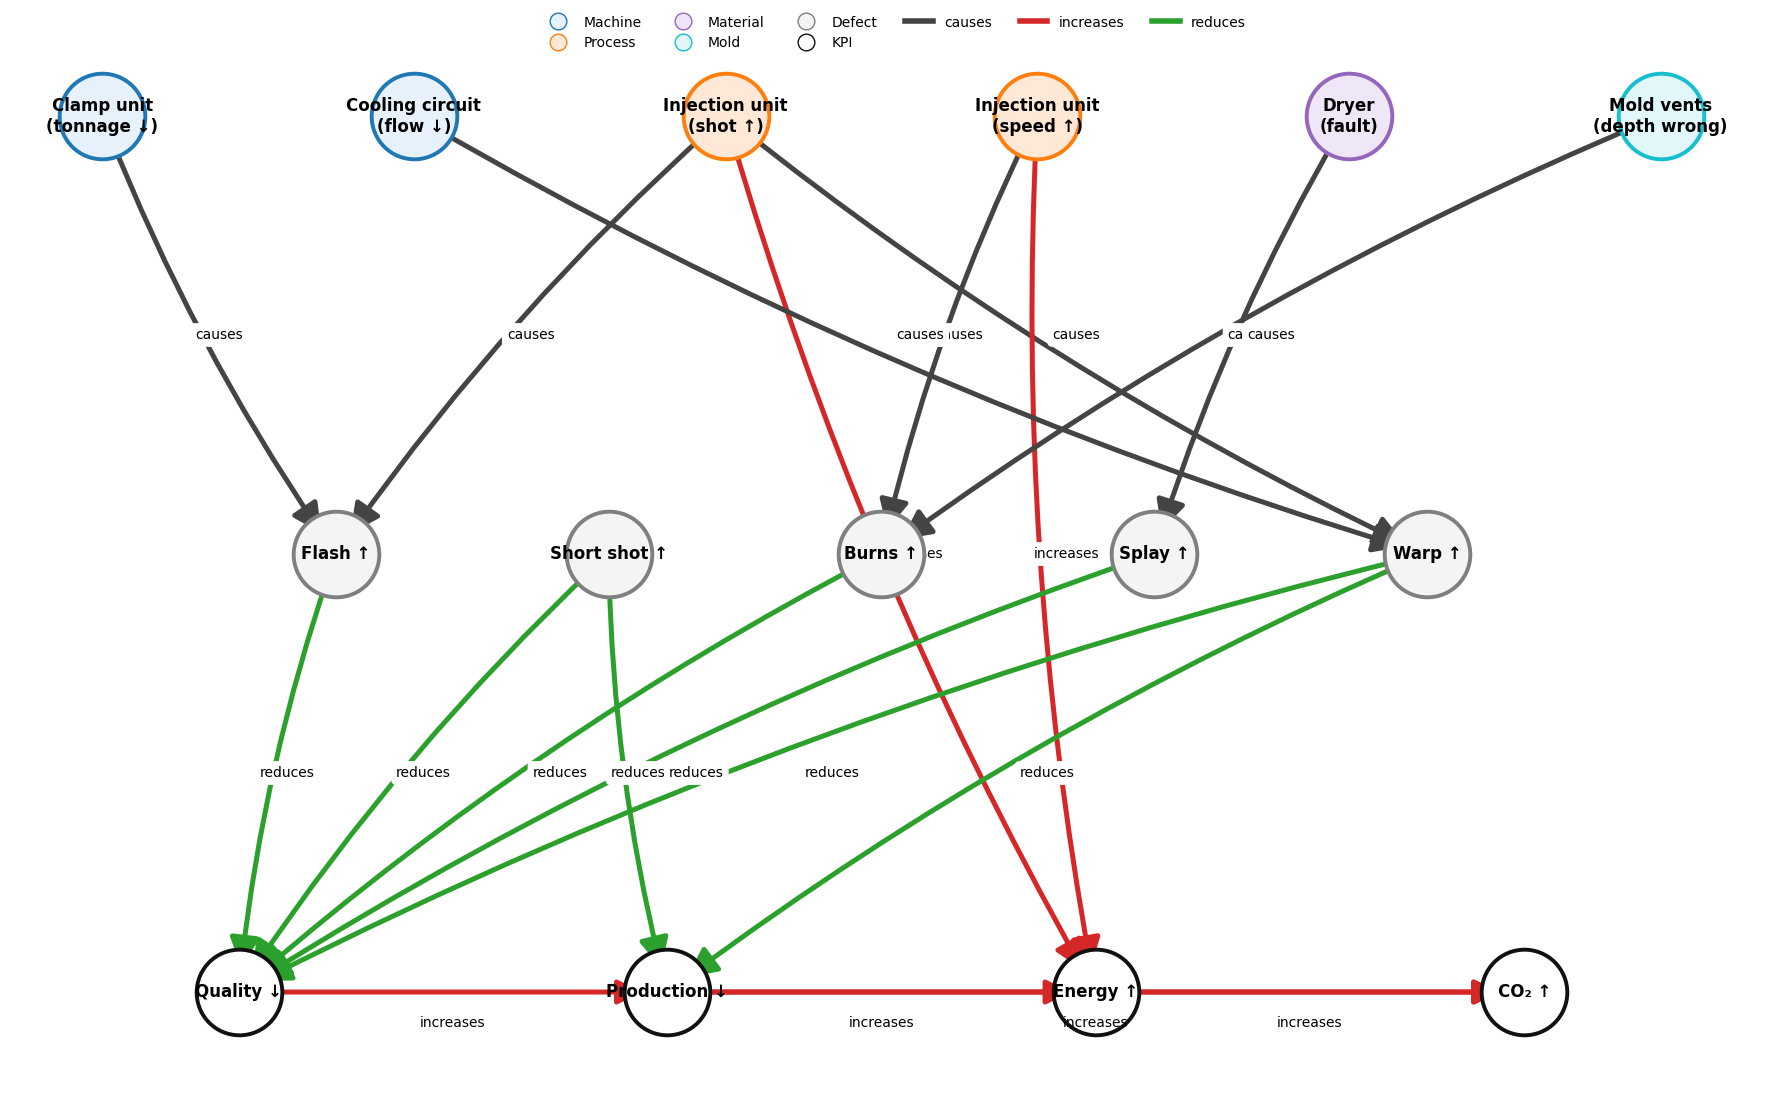

In [19]:
# %%
# XQuality causal graph — reduced top row (1–2 nodes per class) + KPI label fix

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from pathlib import Path

# -------------------- Full catalog of nodes --------------------
nodes = [
    ("CLAMP",   "Clamp unit\n(tonnage ↓)", "machine"),
    ("HPUMP",   "Hydraulic pump\n(pressure ↓)", "machine"),
    ("SHOT",    "Injection unit\n(shot ↑)", "process"),
    ("SPEED",   "Injection unit\n(speed ↑)", "process"),
    ("BZ2",     "Barrel Z2\n(temp ↑)", "process"),
    ("NOZZLE",  "Nozzle\n(temp ↑)", "process"),
    ("NRV",     "Check ring\n(leak)", "machine"),
    ("DRYER",   "Dryer\n(fault)", "material"),
    ("COOL",    "Cooling circuit\n(flow ↓)", "machine"),
    ("VENT",    "Mold vents\n(depth wrong)", "mold"),
    ("PLINE",   "Parting line\n(damaged)", "mold"),
    ("FLASH",   "Flash ↑", "defect"),
    ("SHORT",   "Short shot ↑", "defect"),
    ("BURNS",   "Burns ↑", "defect"),
    ("SPLAY",   "Splay ↑", "defect"),
    ("WARP",    "Warp ↑", "defect"),
    ("QUAL",    "Quality ↓", "kpi"),
    ("PROD",    "Production ↓", "kpi"),
    ("ENERGY",  "Energy ↑", "kpi"),
    ("CO2",     "CO₂ ↑", "kpi"),
]

edges = [
    ("CLAMP","FLASH","causes"),
    ("HPUMP","SHORT","causes"),
    ("NRV","SHORT","causes"),
    ("SHOT","FLASH","causes"),
    ("SHOT","WARP","causes"),
    ("SPEED","BURNS","causes"),
    ("BZ2","BURNS","causes"),
    ("NOZZLE","BURNS","causes"),
    ("DRYER","SPLAY","causes"),
    ("COOL","WARP","causes"),
    ("VENT","BURNS","causes"),
    ("PLINE","FLASH","causes"),
    ("FLASH","QUAL","reduces"),
    ("SHORT","QUAL","reduces"),
    ("BURNS","QUAL","reduces"),
    ("SPLAY","QUAL","reduces"),
    ("WARP","QUAL","reduces"),
    ("SHORT","PROD","reduces"),
    ("WARP","PROD","reduces"),
    ("BZ2","ENERGY","increases"),
    ("SPEED","ENERGY","increases"),
    ("SHOT","ENERGY","increases"),
    ("ENERGY","CO2","increases"),
    ("PROD","ENERGY","increases"),
    ("PROD","CO2","increases"),
    ("QUAL","PROD","increases"),
]

theme_color = {
    "machine": ("#1f77b4", "#e6f1fb"),
    "process": ("#ff7f0e", "#ffe9d6"),
    "material":("#9467bd", "#efe6f7"),
    "mold":    ("#17becf", "#e1f7fa"),
    "defect":  ("#7f7f7f", "#f4f4f4"),
    "kpi":     ("#111111", "#ffffff"),
}
edge_palette = {"causes":"#444444", "increases":"#d62728", "reduces":"#2ca02c"}

# -------------------- Choose a *reduced* top row --------------------
# one/two per class: machine(2), process(2), material(1), mold(1)
top = ["CLAMP", "COOL",  # machine
       "SHOT", "SPEED",  # process
       "DRYER",          # material
       "VENT"]           # mold

mid = ["FLASH","SHORT","BURNS","SPLAY","WARP"]
bot = ["QUAL","PROD","ENERGY","CO2"]

allowed = set(top + mid + bot)

# Filter nodes/edges to only what's used
nodes_filtered = [t for t in nodes if t[0] in allowed]
edges_filtered = [(u,v,r) for (u,v,r) in edges if u in allowed and v in allowed]

# -------------------- Build graph --------------------
G = nx.DiGraph()
for nid, label, theme in nodes_filtered:
    G.add_node(nid, label=label, theme=theme)
for u, v, rel in edges_filtered:
    G.add_edge(u, v, relation=rel)

# -------------------- Layout --------------------
x_spacing_top = 3.2
x_spacing_mid = 2.8
x_spacing_bot = 4.4

def place_row(ids, y, spacing):
    start_x = -(len(ids)-1)/2 * spacing
    return {nid:(start_x+i*spacing, y) for i, nid in enumerate(ids)}

pos = {}
pos.update(place_row(top,  0.0,  x_spacing_top))
pos.update(place_row(mid, -2.6,  x_spacing_mid))
pos.update(place_row(bot, -5.2,  x_spacing_bot))

# -------------------- Draw --------------------
plt.figure(figsize=(18, 11))
ax = plt.gca()

kpi_set = set(bot)
kpi_edges = [(u,v,d) for u,v,d in G.edges(data=True) if u in kpi_set and v in kpi_set]
other_edges = [(u,v,d) for u,v,d in G.edges(data=True) if not (u in kpi_set and v in kpi_set)]

# Non-KPI edges (curved)
for u, v, d in other_edges:
    color = edge_palette.get(d["relation"], "#000")
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u,v)],
        arrows=True, arrowstyle='-|>', arrowsize=44,
        width=3.6, edge_color=color, connectionstyle="arc3,rad=0.06",
        min_source_margin=12, min_target_margin=18
    )

# KPI↔KPI edges (straight, smaller arrowhead)
for u, v, d in kpi_edges:
    color = edge_palette.get(d["relation"], "#000")
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u,v)],
        arrows=True, arrowstyle='-|>', arrowsize=36,
        width=3.6, edge_color=color, connectionstyle="arc3,rad=0.0",
        min_source_margin=12, min_target_margin=18
    )

# Nodes by theme
for theme, (edgec, facec) in theme_color.items():
    sel = [n for n in G.nodes if G.nodes[n]["theme"] == theme]
    if sel:
        nx.draw_networkx_nodes(
            G, pos, nodelist=sel, node_shape="o", node_size=3800,
            linewidths=2.8, edgecolors=edgec, node_color=facec
        )

# Node labels
labels = {n: G.nodes[n]["label"] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=12, font_weight="bold")

# Edge labels for non-KPI edges
edge_labels_other = {(u,v): d["relation"] for u,v,d in other_edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_other,
                             font_size=10, label_pos=0.5, rotate=False)

# KPI edge labels: centered, nudged down
label_offset = -0.18
for (u, v, d) in kpi_edges:
    (x0, y0), (x1, y1) = pos[u], pos[v]
    mx, my = (x0 + x1) / 2.0, (y0 + y1) / 2.0
    dx, dy = (x1 - x0), (y1 - y0)
    L = (dx*dx + dy*dy) ** 0.5 or 1.0
    ux, uy = dx / L, dy / L
    px, py = -uy, ux
    ax.text(mx + label_offset*px, my + label_offset*py, d["relation"],
            fontsize=10, ha="center", va="center")

# Legend
legend_nodes = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["machine"][1],
           markeredgecolor=theme_color["machine"][0], label='Machine', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["process"][1],
           markeredgecolor=theme_color["process"][0], label='Process', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["material"][1],
           markeredgecolor=theme_color["material"][0], label='Material', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["mold"][1],
           markeredgecolor=theme_color["mold"][0], label='Mold', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["defect"][1],
           markeredgecolor=theme_color["defect"][0], label='Defect', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["kpi"][1],
           markeredgecolor=theme_color["kpi"][0], label='KPI', markersize=12),
]
legend_edges = [
    Line2D([0],[0], color=edge_palette["causes"], lw=4, label="causes"),
    Line2D([0],[0], color=edge_palette["increases"], lw=4, label="increases"),
    Line2D([0],[0], color=edge_palette["reduces"], lw=4, label="reduces"),
]
plt.legend(handles=legend_nodes + legend_edges, loc='upper center',
           ncol=6, frameon=False, bbox_to_anchor=(0.5, 1.02))

plt.axis("off")
plt.tight_layout()

# -------------------- Save (relative to notebook folder) --------------------
out_dir = Path.cwd() / "data" / "xquality_example"
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "xquality_tree_machine_parts.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / "xquality_tree_machine_parts.svg", bbox_inches="tight")


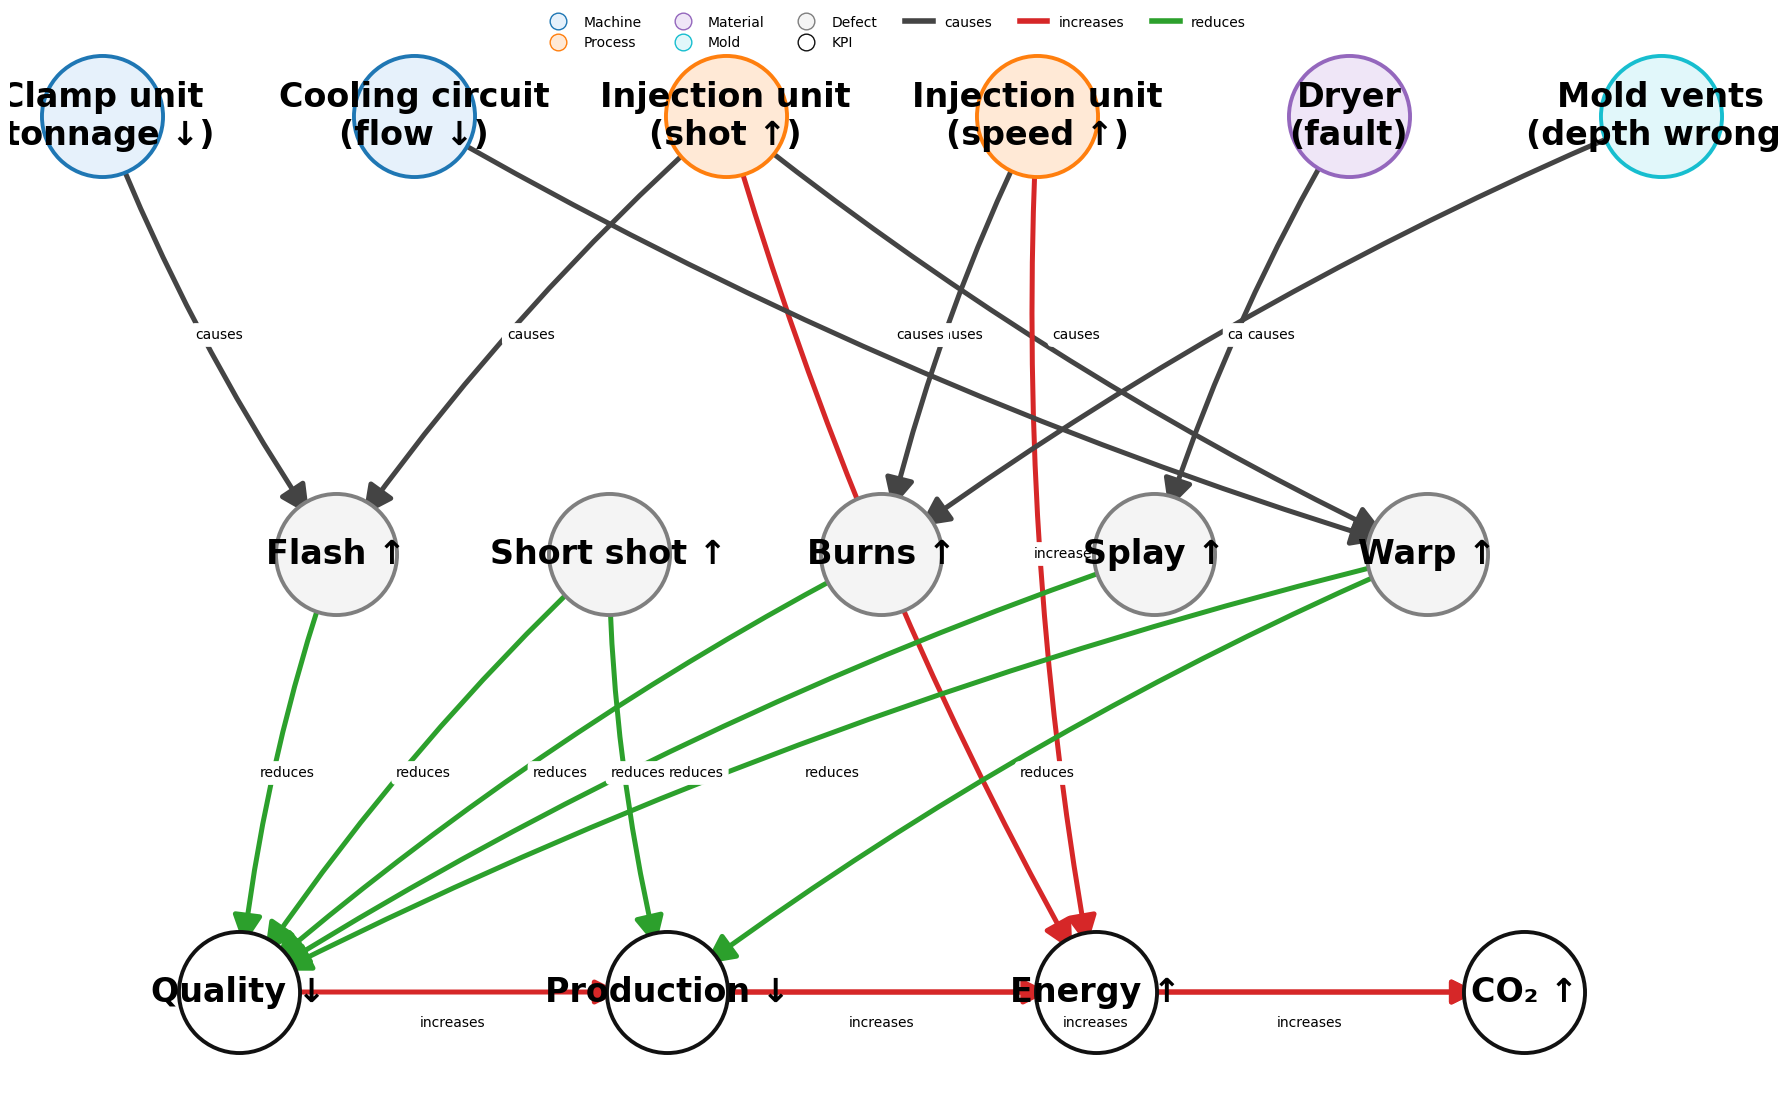

In [20]:
# %%
# XQuality causal graph — preferred layout
# Nodes ×2 size, node labels ×2 font, edge labels unchanged,
# arrowheads kept clear of node borders.

import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from pathlib import Path

# -------------------- Full catalog of nodes --------------------
nodes = [
    ("CLAMP",   "Clamp unit\n(tonnage ↓)", "machine"),
    ("HPUMP",   "Hydraulic pump\n(pressure ↓)", "machine"),
    ("SHOT",    "Injection unit\n(shot ↑)", "process"),
    ("SPEED",   "Injection unit\n(speed ↑)", "process"),
    ("BZ2",     "Barrel Z2\n(temp ↑)", "process"),
    ("NOZZLE",  "Nozzle\n(temp ↑)", "process"),
    ("NRV",     "Check ring\n(leak)", "machine"),
    ("DRYER",   "Dryer\n(fault)", "material"),
    ("COOL",    "Cooling circuit\n(flow ↓)", "machine"),
    ("VENT",    "Mold vents\n(depth wrong)", "mold"),
    ("PLINE",   "Parting line\n(damaged)", "mold"),
    ("FLASH",   "Flash ↑", "defect"),
    ("SHORT",   "Short shot ↑", "defect"),
    ("BURNS",   "Burns ↑", "defect"),
    ("SPLAY",   "Splay ↑", "defect"),
    ("WARP",    "Warp ↑", "defect"),
    ("QUAL",    "Quality ↓", "kpi"),
    ("PROD",    "Production ↓", "kpi"),
    ("ENERGY",  "Energy ↑", "kpi"),
    ("CO2",     "CO₂ ↑", "kpi"),
]

edges = [
    ("CLAMP","FLASH","causes"),
    ("HPUMP","SHORT","causes"),
    ("NRV","SHORT","causes"),
    ("SHOT","FLASH","causes"),
    ("SHOT","WARP","causes"),
    ("SPEED","BURNS","causes"),
    ("BZ2","BURNS","causes"),
    ("NOZZLE","BURNS","causes"),
    ("DRYER","SPLAY","causes"),
    ("COOL","WARP","causes"),
    ("VENT","BURNS","causes"),
    ("PLINE","FLASH","causes"),
    ("FLASH","QUAL","reduces"),
    ("SHORT","QUAL","reduces"),
    ("BURNS","QUAL","reduces"),
    ("SPLAY","QUAL","reduces"),
    ("WARP","QUAL","reduces"),
    ("SHORT","PROD","reduces"),
    ("WARP","PROD","reduces"),
    ("BZ2","ENERGY","increases"),
    ("SPEED","ENERGY","increases"),
    ("SHOT","ENERGY","increases"),
    ("ENERGY","CO2","increases"),
    ("PROD","ENERGY","increases"),
    ("PROD","CO2","increases"),
    ("QUAL","PROD","increases"),
]

theme_color = {
    "machine": ("#1f77b4", "#e6f1fb"),
    "process": ("#ff7f0e", "#ffe9d6"),
    "material":("#9467bd", "#efe6f7"),
    "mold":    ("#17becf", "#e1f7fa"),
    "defect":  ("#7f7f7f", "#f4f4f4"),
    "kpi":     ("#111111", "#ffffff"),
}
edge_palette = {"causes":"#444444", "increases":"#d62728", "reduces":"#2ca02c"}

# -------------------- Reduced top row --------------------
top = ["CLAMP", "COOL",  # machine
       "SHOT", "SPEED",  # process
       "DRYER",          # material
       "VENT"]           # mold

mid = ["FLASH","SHORT","BURNS","SPLAY","WARP"]
bot = ["QUAL","PROD","ENERGY","CO2"]

allowed = set(top + mid + bot)
nodes_filtered = [t for t in nodes if t[0] in allowed]
edges_filtered = [(u,v,r) for (u,v,r) in edges if u in allowed and v in allowed]

# -------------------- Build graph --------------------
G = nx.DiGraph()
for nid, label, theme in nodes_filtered:
    G.add_node(nid, label=label, theme=theme)
for u, v, rel in edges_filtered:
    G.add_edge(u, v, relation=rel)

# -------------------- Layout --------------------
x_spacing_top = 3.2
x_spacing_mid = 2.8
x_spacing_bot = 4.4

def place_row(ids, y, spacing):
    start_x = -(len(ids)-1)/2 * spacing
    return {nid:(start_x+i*spacing, y) for i, nid in enumerate(ids)}

pos = {}
pos.update(place_row(top,  0.0,  x_spacing_top))
pos.update(place_row(mid, -2.6,  x_spacing_mid))
pos.update(place_row(bot, -5.2,  x_spacing_bot))

# -------------------- Draw --------------------
plt.figure(figsize=(18, 11))
ax = plt.gca()

kpi_set = set(bot)
kpi_edges = [(u,v,d) for u,v,d in G.edges(data=True) if u in kpi_set and v in kpi_set]
other_edges = [(u,v,d) for u,v,d in G.edges(data=True) if not (u in kpi_set and v in kpi_set)]

# Increase margins so arrowheads don't overlap bigger nodes
TARGET_MARGIN = 34  # was 18; increased to keep arrowhead clear
SOURCE_MARGIN = 14

# Non-KPI edges (curved)
for u, v, d in other_edges:
    color = edge_palette.get(d["relation"], "#000")
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u,v)],
        arrows=True, arrowstyle='-|>', arrowsize=44,
        width=3.6, edge_color=color, connectionstyle="arc3,rad=0.06",
        min_source_margin=SOURCE_MARGIN, min_target_margin=TARGET_MARGIN
    )

# KPI↔KPI edges (straight, smaller arrowhead)
for u, v, d in kpi_edges:
    color = edge_palette.get(d["relation"], "#000")
    nx.draw_networkx_edges(
        G, pos, edgelist=[(u,v)],
        arrows=True, arrowstyle='-|>', arrowsize=36,
        width=3.6, edge_color=color, connectionstyle="arc3,rad=0.0",
        min_source_margin=SOURCE_MARGIN, min_target_margin=TARGET_MARGIN
    )

# Nodes by theme — 2× bigger
for theme, (edgec, facec) in theme_color.items():
    sel = [n for n in G.nodes if G.nodes[n]["theme"] == theme]
    if sel:
        nx.draw_networkx_nodes(
            G, pos, nodelist=sel, node_shape="o", node_size=7600,  # doubled
            linewidths=2.8, edgecolors=edgec, node_color=facec
        )

# Node labels — 2× font
labels = {n: G.nodes[n]["label"] for n in G.nodes()}
nx.draw_networkx_labels(G, pos, labels=labels, font_size=24, font_weight="bold")

# Edge labels for non-KPI edges — unchanged font
edge_labels_other = {(u,v): d["relation"] for u,v,d in other_edges}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_other,
                             font_size=10, label_pos=0.5, rotate=False)

# KPI edge labels — unchanged font, centered and nudged down
label_offset = -0.18
for (u, v, d) in kpi_edges:
    (x0, y0), (x1, y1) = pos[u], pos[v]
    mx, my = (x0 + x1) / 2.0, (y0 + y1) / 2.0
    dx, dy = (x1 - x0), (y1 - y0)
    L = (dx*dx + dy*dy) ** 0.5 or 1.0
    ux, uy = dx / L, dy / L
    px, py = -uy, ux
    ax.text(mx + label_offset*px, my + label_offset*py, d["relation"],
            fontsize=10, ha="center", va="center")

# Legend (kept at original size because you preferred this version)
legend_nodes = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["machine"][1],
           markeredgecolor=theme_color["machine"][0], label='Machine', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["process"][1],
           markeredgecolor=theme_color["process"][0], label='Process', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["material"][1],
           markeredgecolor=theme_color["material"][0], label='Material', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["mold"][1],
           markeredgecolor=theme_color["mold"][0], label='Mold', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["defect"][1],
           markeredgecolor=theme_color["defect"][0], label='Defect', markersize=12),
    Line2D([0],[0], marker='o', color='w', markerfacecolor=theme_color["kpi"][1],
           markeredgecolor=theme_color["kpi"][0], label='KPI', markersize=12),
]
legend_edges = [
    Line2D([0],[0], color=edge_palette["causes"], lw=4, label="causes"),
    Line2D([0],[0], color=edge_palette["increases"], lw=4, label="increases"),
    Line2D([0],[0], color=edge_palette["reduces"], lw=4, label="reduces"),
]
plt.legend(handles=legend_nodes + legend_edges, loc='upper center',
           ncol=6, frameon=False, bbox_to_anchor=(0.5, 1.02))

plt.axis("off")
plt.tight_layout()

# -------------------- Save (relative to notebook folder) --------------------
out_dir = Path.cwd() / "data" / "xquality_example"
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / "xquality_tree_machine_parts.png", dpi=300, bbox_inches="tight")
plt.savefig(out_dir / "xquality_tree_machine_parts.svg", bbox_inches="tight")
